# Ciclos, estabilidade e bifurcações em sistemas predador-presa

Nos exemplos anteriores, vimos como resolver sistemas de ODE e como comparar métodos numéricos. Agora vamos olhar para outra pergunta:

**como o comportamento qualitativo de um sistema dinâmico muda quando variamos um parâmetro?**

A ideia é estudar, em um modelo predador-presa, quando aparecem:

* extinção de predadores;
* coexistência estável entre presas e predadores;
* oscilações persistentes, associadas a um ciclo limite.

O modelo de Lotka-Volterra clássico é um bom ponto de partida, mas ele é conservativo demais para esta pergunta: no quadrante positivo, as trajetórias ficam em órbitas fechadas determinadas pela condição inicial, sem atração assintótica para um equilíbrio ou ciclo limite. Para ver transições de estabilidade e bifurcações de forma mais clara, vamos usar uma extensão com crescimento logístico das presas e predação saturante.

## Importando as dependências

Usaremos `numpy`, `pandas`, `matplotlib` e `solve_ivp`, mantendo a mesma estrutura dos notebooks anteriores.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp

plt.rcParams.update(
    {
        "axes.grid": True,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "figure.figsize": (8, 4.5),
        "font.size": 11,
    }
)

## Modelo de Rosenzweig-MacArthur

Vamos considerar o sistema

$$
\begin{aligned}
x'(t) &= r x\left(1-\frac{x}{K}\right)-\phi(x)y,\\
y'(t) &= \left(e\phi(x)-m\right)y,
\end{aligned}
$$

em que

$$
\phi(x)=\frac{a x}{1+b x}.
$$

Aqui:

* $x(t)$ representa a população de presas;
* $y(t)$ representa a população de predadores;
* $r$ é a taxa de crescimento das presas;
* $K$ é a capacidade de suporte das presas;
* $\phi(x)$ é a taxa efetiva de predação;
* $a$ controla a intensidade de predação;
* $b$ controla a saturação da predação;
* $e$ é a eficiência de conversão de presas em predadores;
* $m$ é a mortalidade dos predadores.

A diferença essencial em relação ao Lotka-Volterra clássico é que as presas não crescem indefinidamente na ausência de predadores, pois o termo logístico empurra $x(t)$ para $K$. Além disso, a predação satura para populações grandes de presas.

In [2]:
r_growth = 1.0
a_attack = 1.0
b_saturation = 0.2
e_conversion = 0.5
m_mortality = 0.3

base_params = {
    "r": r_growth,
    "a": a_attack,
    "b": b_saturation,
    "e": e_conversion,
    "m": m_mortality,
}


def resposta_funcional(x, a, b):
    return a * x / (1.0 + b * x)


def resposta_funcional_derivada(x, a, b):
    return a / (1.0 + b * x) ** 2


def parametros_com_K(K):
    return (
        base_params["r"],
        K,
        base_params["a"],
        base_params["b"],
        base_params["e"],
        base_params["m"],
    )


def rm_rhs(t, state, r, K, a, b, e, m):
    x, y = state
    phi = resposta_funcional(x, a, b)

    dxdt = r * x * (1.0 - x / K) - phi * y
    dydt = (e * phi - m) * y

    return np.array([dxdt, dydt], dtype=float)


def rm_jacobian(state, r, K, a, b, e, m):
    x, y = state
    phi = resposta_funcional(x, a, b)
    dphi = resposta_funcional_derivada(x, a, b)

    return np.array(
        [
            [r * (1.0 - 2.0 * x / K) - dphi * y, -phi],
            [e * dphi * y, e * phi - m],
        ],
        dtype=float,
    )


pd.DataFrame(
    {
        "parâmetro": ["r", "a", "b", "e", "m"],
        "valor": [
            r_growth,
            a_attack,
            b_saturation,
            e_conversion,
            m_mortality,
        ],
    }
)

,parâmetro,valor
0,r,1.0
1,a,1.0
2,b,0.2
3,e,0.5
4,m,0.3


O parâmetro que vamos variar será $K$. Biologicamente, ele mede a disponibilidade de recursos para as presas. Matematicamente, ele será nosso parâmetro de bifurcação.

## Equilíbrios e coexistência

Um equilíbrio é um ponto $(x^*,y^*)$ em que

$$
x'=0
\qquad\text{e}\qquad
y'=0.
$$

Ou seja, se a trajetória começar exatamente nesse ponto, ela permanece nele.

Neste modelo, há três equilíbrios relevantes:

$$
E_0=(0,0),
$$

$$
E_K=(K,0),
$$

e, quando existir no quadrante positivo, um equilíbrio de coexistência

$$
E_*=(x_*,y_*).
$$

O equilíbrio de coexistência vem da condição $y'=0$ com $y>0$. Como

$$
y'=\left(e\phi(x)-m\right)y,
$$

precisamos ter

$$
e\phi(x_*)=m.
$$

Substituindo $\phi(x)=a x/(1+b x)$, obtemos

$$
x_*=\frac{m}{ea-mb}.
$$

Depois, substituímos $x_*$ na equação $x'=0$ para encontrar

$$
y_*=\frac{r x_*\left(1-x_*/K\right)}{\phi(x_*)}.
$$

Portanto, a coexistência só faz sentido biologicamente quando $x_*>0$ e $y_*>0$. Como $y_*>0$ exige $K>x_*$, o valor $x_*$ também é o limiar de invasão dos predadores: se $K$ for pequeno demais, os predadores não conseguem se manter.

O segundo limiar importante é $K_{\mathrm{Hopf}}$. Ele é o valor de $K$ em que o equilíbrio de coexistência troca de estabilidade por uma bifurcação de Hopf.

Uma bifurcação de Hopf ocorre quando, ao variar um parâmetro, um equilíbrio muda de estabilidade através de um par de autovalores complexos conjugados que atravessa o eixo imaginário. Em termos práticos, isso significa que uma espiral atrativa pode se transformar em uma espiral repulsiva, e essa mudança pode vir acompanhada do nascimento de oscilações periódicas.

No nosso caso, antes da bifurcação, trajetórias próximas ao equilíbrio de coexistência espiralam para ele. Depois da bifurcação, elas se afastam desse equilíbrio e passam a se aproximar de um ciclo limite. Esse ciclo representa oscilações sustentadas de presas e predadores.

Para enxergar de onde ele vem, avaliamos o Jacobiano no equilíbrio $E_*=(x_*,y_*)$. Para o sistema

$$
\begin{aligned}
f_1(x,y)&=r x\left(1-\frac{x}{K}\right)-\phi(x)y,\\
f_2(x,y)&=\left(e\phi(x)-m\right)y,
\end{aligned}
$$

o Jacobiano é

$$
J(x,y)=
\begin{bmatrix}
r\left(1-\frac{2x}{K}\right)-\phi'(x)y & -\phi(x)\\
e\phi'(x)y & e\phi(x)-m
\end{bmatrix}.
$$

Em um sistema bidimensional, a estabilidade local é controlada pelo traço e pelo determinante do Jacobiano:

$$
\operatorname{tr}(J_*)=\lambda_1+\lambda_2,
\qquad
\det(J_*)=\lambda_1\lambda_2.
$$

No equilíbrio de coexistência, temos $e\phi(x_*)=m$. Portanto, o termo inferior direito do Jacobiano se anula em $E_*$, e o traço fica

$$
\operatorname{tr}(J_*)=
r\left(1-\frac{2x_*}{K}\right)-\phi'(x_*)y_*.
$$

Além disso,

$$
\det(J_*)=e\phi(x_*)\phi'(x_*)y_* > 0
$$

no regime de coexistência. Assim, a mudança de estabilidade ocorre quando o traço passa por zero.

Agora substituímos

$$
y_*=\frac{r x_*\left(1-x_*/K\right)}{\phi(x_*)}
$$

na expressão do traço:

$$
\operatorname{tr}(J_*)=
r\left(1-\frac{2x_*}{K}\right)
-
r x_*\left(1-\frac{x_*}{K}\right)
\frac{\phi'(x_*)}{\phi(x_*)}.
$$

Para a resposta funcional

$$
\phi(x)=\frac{a x}{1+b x},
$$

temos

$$
\phi'(x)=\frac{a}{(1+b x)^2}
$$

e, consequentemente,

$$
\frac{\phi'(x_*)}{\phi(x_*)}
=
\frac{1}{x_*(1+b x_*)}.
$$

Substituindo essa razão no traço, obtemos

$$
\operatorname{tr}(J_*)=
r\left[
1-\frac{2x_*}{K}
-
\frac{1-x_*/K}{1+b x_*}
\right].
$$

A bifurcação de Hopf ocorre quando

$$
\operatorname{tr}(J_*)=0,
$$

isto é,

$$
1-\frac{2x_*}{K}
=
\frac{1-x_*/K}{1+b x_*}.
$$

Multiplicando por $1+b x_*$,

$$
(1+b x_*)\left(1-\frac{2x_*}{K}\right)
=
1-\frac{x_*}{K}.
$$

Expandindo e simplificando,

$$
b x_*-\frac{x_*}{K}-\frac{2b x_*^2}{K}=0.
$$

Como estamos no equilíbrio de coexistência, $x_*>0$. Então podemos dividir por $x_*$:

$$
b-\frac{1+2b x_*}{K}=0.
$$

Logo,

$$
K_{\mathrm{Hopf}}=\frac{1}{b}+2x_*.
$$

Portanto, $K_{\mathrm{Hopf}}$ não é um parâmetro novo do modelo. Ele é um valor crítico calculado a partir dos parâmetros do problema. Para $K<K_{\mathrm{Hopf}}$, o equilíbrio de coexistência é atrativo; para $K>K_{\mathrm{Hopf}}$, ele se torna instável e a dinâmica passa a apresentar oscilações persistentes ao redor dele.

In [3]:
def x_coexistencia(base_params):
    a = base_params["a"]
    b = base_params["b"]
    e = base_params["e"]
    m = base_params["m"]

    denominator = e * a - m * b
    if denominator <= 0.0:
        return np.nan

    return m / denominator


def equilibrio_coexistencia(K):
    params = parametros_com_K(K)
    r, K, a, b, e, m = params
    x_star = x_coexistencia(base_params)

    if not np.isfinite(x_star) or K <= x_star:
        return None

    phi_star = resposta_funcional(x_star, a, b)
    y_star = r * x_star * (1.0 - x_star / K) / phi_star

    return np.array([x_star, y_star], dtype=float)


def equilibrios(K):
    eqs = {
        "extinção total": np.array([0.0, 0.0]),
        "sem predadores": np.array([K, 0.0]),
    }

    coexistencia = equilibrio_coexistencia(K)
    if coexistencia is not None:
        eqs["coexistência"] = coexistencia

    return eqs


def K_hopf(base_params):
    b = base_params["b"]
    x_star = x_coexistencia(base_params)

    if b <= 0.0 or not np.isfinite(x_star):
        return np.inf

    return 1.0 / b + 2.0 * x_star


x_star_threshold = x_coexistencia(base_params)
K_hopf_threshold = K_hopf(base_params)

pd.DataFrame(
    {
        "quantidade": [
            "x* da coexistência",
            "limiar de invasão dos predadores",
            "K da bifurcação de Hopf",
        ],
        "valor": [
            x_star_threshold,
            x_star_threshold,
            K_hopf_threshold,
        ],
    }
)

,quantidade,valor
0,x* da coexistência,0.681818
1,limiar de invasão dos predadores,0.681818
2,K da bifurcação de Hopf,6.363636


Com esses parâmetros, os regimes esperados são:

* se $K<x_*$, os predadores são extintos e o sistema tende a $(K,0)$;
* se $x_*<K<K_{\mathrm{Hopf}}$, presas e predadores coexistem em um equilíbrio estável;
* se $K>K_{\mathrm{Hopf}}$, o equilíbrio de coexistência perde estabilidade e aparece um ciclo limite.

O ponto $K=x_*$ marca a entrada dos predadores no sistema. Já $K=K_{\mathrm{Hopf}}$ marca uma mudança de estabilidade do equilíbrio de coexistência.

In [4]:
pd.DataFrame(
    {
        "condição sobre K": [
            f"K < {x_star_threshold:.3f}",
            f"{x_star_threshold:.3f} < K < {K_hopf_threshold:.3f}",
            f"K > {K_hopf_threshold:.3f}",
        ],
        "regime esperado": [
            "extinção de predadores",
            "coexistência estável",
            "ciclo limite",
        ],
    }
)

,condição sobre K,regime esperado
0,K < 0.682,extinção de predadores
1,0.682 < K < 6.364,coexistência estável
2,K > 6.364,ciclo limite


## Estabilidade local pelo Jacobiano

Para classificar um equilíbrio, linearizamos o sistema ao redor dele. Se $\mathbf{z}=(x,y)$, o Jacobiano é

$$
J(\mathbf{z})=
\begin{bmatrix}
\partial f_1/\partial x & \partial f_1/\partial y\\
\partial f_2/\partial x & \partial f_2/\partial y
\end{bmatrix}.
$$

A interpretação básica dos autovalores de $J$ é:

* partes reais negativas indicam atração local;
* alguma parte real positiva indica instabilidade local;
* autovalores complexos com parte real negativa indicam aproximação em espiral;
* autovalores complexos com parte real positiva indicam afastamento em espiral.

Essa análise é local: ela descreve o comportamento perto do equilíbrio. Para ciclos e comportamento global, ainda precisamos olhar as trajetórias.

In [5]:
def formatar_ponto(point):
    return f"({point[0]:.4f}, {point[1]:.4f})"


def formatar_autovalores(eigenvalues):
    return ", ".join(f"{eig.real:+.4f}{eig.imag:+.4f}i" for eig in eigenvalues)


def classificar_autovalores(eigenvalues, tol=1e-9):
    real_parts = np.real(eigenvalues)
    max_real = np.max(real_parts)
    has_complex = np.max(np.abs(np.imag(eigenvalues))) > tol

    if max_real < -tol:
        return "estável em espiral" if has_complex else "estável"

    if max_real > tol:
        if np.any(real_parts < -tol) and np.any(real_parts > tol):
            return "sela"
        return "instável em espiral" if has_complex else "instável"

    return "caso crítico"


K_examples = [0.5, 3.0, 9.0]

stability_rows = []
for K in K_examples:
    params = parametros_com_K(K)
    for name, point in equilibrios(K).items():
        eigenvalues = np.linalg.eigvals(rm_jacobian(point, *params))
        stability_rows.append(
            {
                "K": K,
                "equilíbrio": name,
                "ponto": formatar_ponto(point),
                "autovalores": formatar_autovalores(eigenvalues),
                "classificação local": classificar_autovalores(eigenvalues),
            }
        )

pd.DataFrame(stability_rows)

,K,equilíbrio,ponto,autovalores,classificação local
0,0.5,extinção total,"(0.0000, 0.0000)","+1.0000+0.0000i, -0.3000+0.0000i",sela
1,0.5,sem predadores,"(0.5000, 0.0000)","-1.0000+0.0000i, -0.0727+0.0000i",estável
2,3.0,extinção total,"(0.0000, 0.0000)","+1.0000+0.0000i, -0.3000+0.0000i",sela
3,3.0,sem predadores,"(3.0000, 0.0000)","-1.0000+0.0000i, +0.6375+0.0000i",sela
4,3.0,coexistência,"(0.6818, 0.8781)","-0.0673+0.4466i, -0.0673-0.4466i",estável em espiral
5,9.0,extinção total,"(0.0000, 0.0000)","+1.0000+0.0000i, -0.3000+0.0000i",sela
6,9.0,sem predadores,"(9.0000, 0.0000)","-1.0000+0.0000i, +1.3071+0.0000i",sela
7,9.0,coexistência,"(0.6818, 1.0503)","+0.0176+0.4937i, +0.0176-0.4937i",instável em espiral


A tabela mostra a troca de estabilidade de forma bem direta. Para $K=0.5$, o equilíbrio sem predadores é estável. Para $K=3$, a coexistência existe e é estável. Para $K=9$, a coexistência ainda existe, mas passa a ser instável em espiral; nesse caso, a trajetória não fica no equilíbrio e tende a um ciclo ao redor dele.

## Simulações em três regimes

Vamos simular três valores representativos de $K$:

$$
K=0.5,\qquad K=3,\qquad K=9.
$$

Esses valores foram escolhidos para cair, respectivamente, nos regimes de extinção de predadores, coexistência estável e ciclo limite.

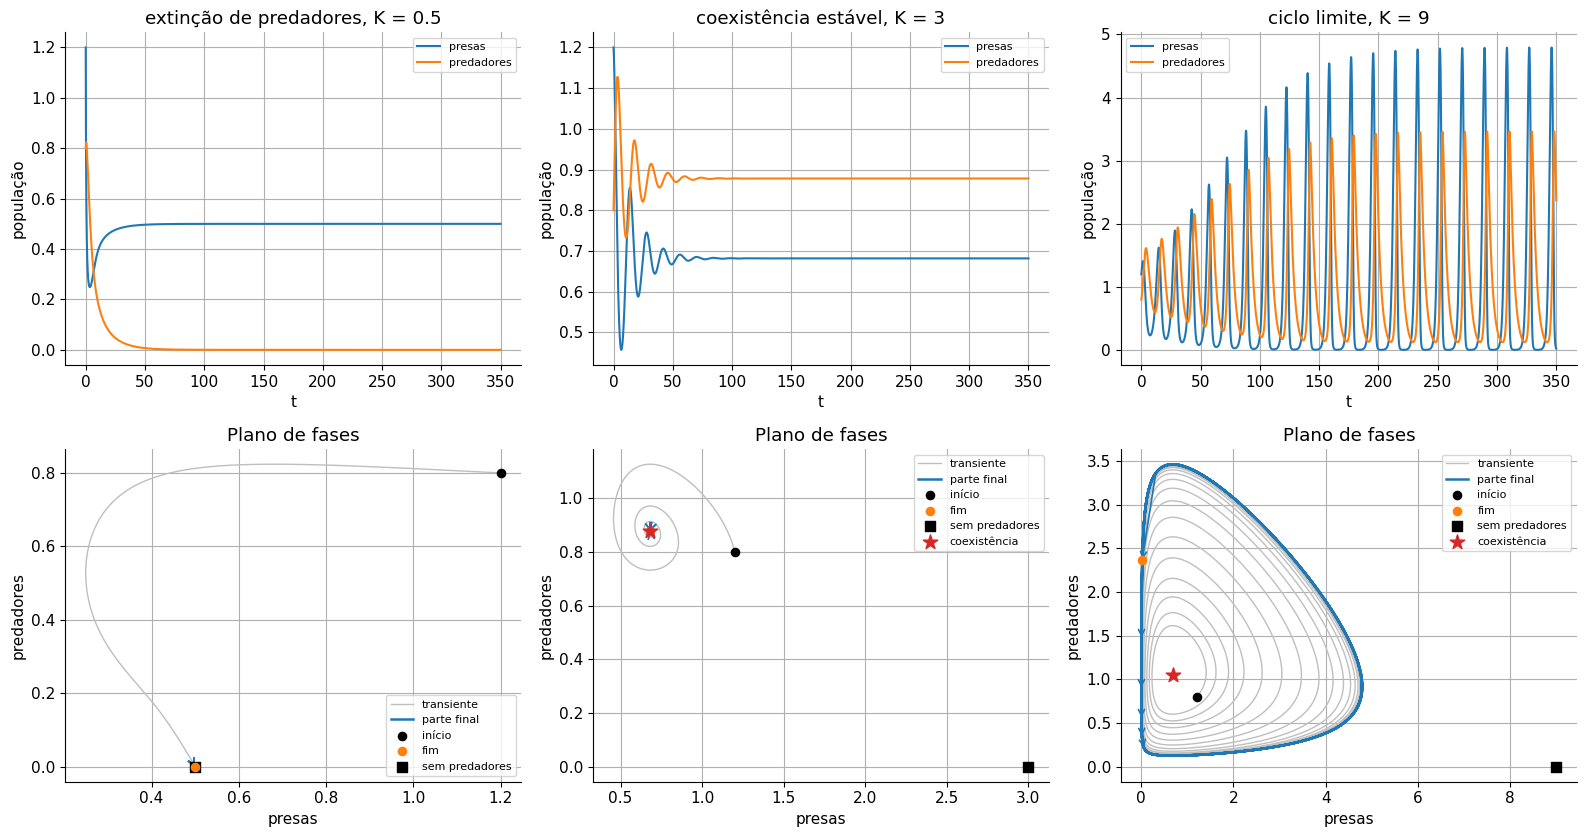

In [6]:
def resolver_rm(K, z0=(1.2, 0.8), T=350.0, n_points=7001, rtol=1e-8, atol=1e-10):
    t_eval = np.linspace(0.0, T, n_points)
    solution = sp.integrate.solve_ivp(
        rm_rhs,
        t_span=(0.0, T),
        y0=np.asarray(z0, dtype=float),
        args=parametros_com_K(K),
        method="LSODA",
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
    )

    return solution


def adicionar_setas_trajetoria(ax, x, y, n_arrows=6, color="tab:blue"):
    if len(x) < 20:
        return

    step = max(2, len(x) // 120)
    indices = np.linspace(step, len(x) - step - 1, n_arrows, dtype=int)

    for index in indices:
        ax.annotate(
            "",
            xy=(x[index + step], y[index + step]),
            xytext=(x[index - step], y[index - step]),
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "lw": 1.2,
                "shrinkA": 0,
                "shrinkB": 0,
            },
        )


def plotar_equilibrios(ax, K):
    eqs = equilibrios(K)

    if "sem predadores" in eqs:
        point = eqs["sem predadores"]
        ax.scatter(
            point[0],
            point[1],
            s=45,
            color="black",
            marker="s",
            label="sem predadores",
            zorder=5,
        )

    if "coexistência" in eqs:
        point = eqs["coexistência"]
        ax.scatter(
            point[0],
            point[1],
            s=120,
            color="tab:red",
            marker="*",
            label="coexistência",
            zorder=6,
        )


simulation_cases = [
    ("extinção de predadores", 0.5),
    ("coexistência estável", 3.0),
    ("ciclo limite", 9.0),
]

solutions_by_K = {K: resolver_rm(K) for _, K in simulation_cases}

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

for column, (label, K) in enumerate(simulation_cases):
    solution = solutions_by_K[K]
    trajectory = solution.y.T
    tail_start = int(0.75 * len(solution.t))

    axes[0, column].plot(solution.t, trajectory[:, 0], label="presas")
    axes[0, column].plot(solution.t, trajectory[:, 1], label="predadores")
    axes[0, column].set_xlabel("t")
    axes[0, column].set_ylabel("população")
    axes[0, column].set_title(f"{label}, K = {K:g}")
    axes[0, column].legend(fontsize=8)

    axes[1, column].plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color="0.75",
        linewidth=1.0,
        label="transiente",
    )
    axes[1, column].plot(
        trajectory[tail_start:, 0],
        trajectory[tail_start:, 1],
        color="tab:blue",
        linewidth=1.8,
        label="parte final",
    )
    adicionar_setas_trajetoria(
        axes[1, column],
        trajectory[tail_start:, 0],
        trajectory[tail_start:, 1],
        color="tab:blue",
    )
    axes[1, column].scatter(
        trajectory[0, 0],
        trajectory[0, 1],
        color="black",
        s=35,
        label="início",
        zorder=6,
    )
    axes[1, column].scatter(
        trajectory[-1, 0],
        trajectory[-1, 1],
        color="tab:orange",
        s=35,
        label="fim",
        zorder=6,
    )
    plotar_equilibrios(axes[1, column], K)
    axes[1, column].set_xlabel("presas")
    axes[1, column].set_ylabel("predadores")
    axes[1, column].set_title("Plano de fases")
    axes[1, column].legend(fontsize=8)

fig.tight_layout()
plt.show()

No primeiro caso, a população de predadores decai para zero e as presas tendem à capacidade de suporte $K$. No segundo, as duas populações se aproximam de um equilíbrio de coexistência. No terceiro, a trajetória se aproxima de uma órbita fechada: depois do transiente, as oscilações persistem.

As setas no plano de fases indicam a direção do movimento. Elas ajudam a distinguir uma trajetória que espirala para um equilíbrio de uma trajetória que se acomoda em um ciclo.

## Nulclinas e interpretação do plano de fases

As nulclinas são curvas em que uma das derivadas se anula.

A nulclina de presas é dada por $x'=0$. Além da reta $x=0$, temos

$$
y=\frac{r x(1-x/K)}{\phi(x)}
=
\frac{r(1-x/K)(1+b x)}{a}.
$$

A nulclina de predadores é dada por $y'=0$. Além da reta $y=0$, temos

$$
x=x_*.
$$

Os equilíbrios aparecem nas interseções das nulclinas. A mudança de estabilidade do equilíbrio de coexistência fica muito clara quando comparamos os casos $K=3$ e $K=9$.

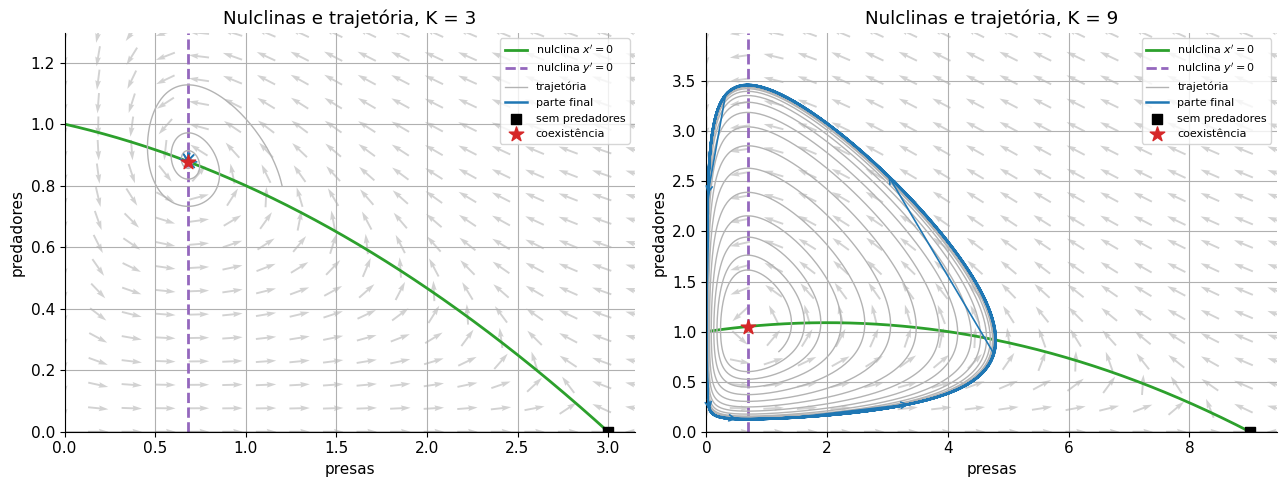

In [7]:
def nulclina_presas(x, K):
    r, K, a, b, e, m = parametros_com_K(K)
    return r * (1.0 - x / K) * (1.0 + b * x) / a


def adicionar_campo_vetorial(ax, K, xmax, ymax, density=18):
    r, K, a, b, e, m = parametros_com_K(K)
    x_grid = np.linspace(0.0, xmax, density)
    y_grid = np.linspace(0.0, ymax, density)
    X, Y = np.meshgrid(x_grid, y_grid)
    Phi = resposta_funcional(X, a, b)
    U = r * X * (1.0 - X / K) - Phi * Y
    V = (e * Phi - m) * Y

    speed = np.hypot(U, V)
    U_scaled = np.divide(U, speed, out=np.zeros_like(U), where=speed > 0.0)
    V_scaled = np.divide(V, speed, out=np.zeros_like(V), where=speed > 0.0)

    ax.quiver(
        X,
        Y,
        U_scaled,
        V_scaled,
        color="0.75",
        alpha=0.7,
        pivot="mid",
        scale=28,
    )


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, K in zip(axes, [3.0, 9.0]):
    solution = solutions_by_K[K]
    trajectory = solution.y.T
    tail_start = int(0.75 * len(solution.t))

    xmax = max(K * 1.05, np.max(trajectory[:, 0]) * 1.05)
    ymax = max(np.max(trajectory[:, 1]) * 1.15, 1.0)

    adicionar_campo_vetorial(ax, K, xmax, ymax)

    x_values = np.linspace(1e-4, K, 500)
    y_prey_nullcline = nulclina_presas(x_values, K)
    ax.plot(
        x_values,
        y_prey_nullcline,
        color="tab:green",
        linewidth=2.0,
        label=r"nulclina $x'=0$",
    )
    ax.axvline(
        x_star_threshold,
        color="tab:purple",
        linestyle="--",
        linewidth=2.0,
        label=r"nulclina $y'=0$",
    )
    ax.axhline(0.0, color="black", linewidth=1.0)

    ax.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color="0.7",
        linewidth=1.0,
        label="trajetória",
    )
    ax.plot(
        trajectory[tail_start:, 0],
        trajectory[tail_start:, 1],
        color="tab:blue",
        linewidth=1.8,
        label="parte final",
    )
    adicionar_setas_trajetoria(
        ax,
        trajectory[tail_start:, 0],
        trajectory[tail_start:, 1],
        n_arrows=5,
        color="tab:blue",
    )
    plotar_equilibrios(ax, K)

    ax.set_xlim(0.0, xmax)
    ax.set_ylim(0.0, ymax)
    ax.set_xlabel("presas")
    ax.set_ylabel("predadores")
    ax.set_title(f"Nulclinas e trajetória, K = {K:g}")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

Para $K=3$, a trajetória cruza as nulclinas e espirala para a interseção. Para $K=9$, a interseção ainda existe, mas é instável; a trajetória se afasta dela e se organiza em torno de um ciclo limite.

Esse é um ponto importante: o equilíbrio de coexistência não desaparece quando o ciclo surge. O que muda é sua estabilidade.

## Diagrama de bifurcação em função de $K$

Agora vamos variar $K$ em uma malha de valores e observar o comportamento depois do transiente. Para cada valor de $K$, fazemos uma simulação em uma janela de tempo relativamente longa, descartamos a parte inicial da trajetória e analisamos apenas o trecho final.

Nesse trecho final, calculamos separadamente

$$
\min_t x(t),\quad \max_t x(t),
\qquad
\min_t y(t),\quad \max_t y(t).
$$

Ou seja: os mínimos e máximos são tomados ao longo do tempo, para cada população separadamente. Não estamos olhando apenas o último instante da simulação, nem tomando mínimo e máximo entre as duas populações.

Se mínimo e máximo praticamente coincidem, a trajetória está se aproximando de um equilíbrio. Se há uma faixa vertical bem aberta, a trajetória está oscilando.

In [8]:
def regime_teorico(K):
    if K < x_star_threshold:
        return "predador extinto"

    if np.isclose(K, x_star_threshold):
        return "bifurcação de invasão"

    if K < K_hopf_threshold:
        return "coexistência estável"

    if np.isclose(K, K_hopf_threshold):
        return "bifurcação de Hopf"

    return "ciclo limite"


K_sweep = np.linspace(0.35, 12.0, 90)
sweep_rows = []

for K in K_sweep:
    solution = resolver_rm(
        K,
        z0=(1.2, 0.8),
        T=260.0,
        n_points=2601,
        rtol=1e-7,
        atol=1e-9,
    )
    trajectory = solution.y.T
    tail = trajectory[int(0.65 * len(trajectory)) :]

    sweep_rows.append(
        {
            "K": K,
            "x_min": np.min(tail[:, 0]),
            "x_max": np.max(tail[:, 0]),
            "y_min": np.min(tail[:, 1]),
            "y_max": np.max(tail[:, 1]),
            "x_mean": np.mean(tail[:, 0]),
            "y_mean": np.mean(tail[:, 1]),
            "regime teórico": regime_teorico(K),
        }
    )

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.head()

,K,x_min,x_max,y_min,y_max,x_mean,y_mean,regime teórico
0,0.350000,0.350000,0.350000,1.713406e-12,3.127267e-11,0.350000,1.706912e-11,predador extinto
1,0.480899,0.480899,0.480899,3.511802e-10,3.415327e-07,0.480899,4.703018e-08,predador extinto
2,0.611798,0.611229,0.611751,8.278738e-05,1.014090e-03,0.611590,3.713719e-04,predador extinto
3,0.742697,0.680990,0.681730,9.327677e-02,9.436556e-02,0.681489,9.363225e-02,coexistência estável
4,0.873596,0.681818,0.681818,2.494619e-01,2.494619e-01,0.681818,2.494619e-01,coexistência estável


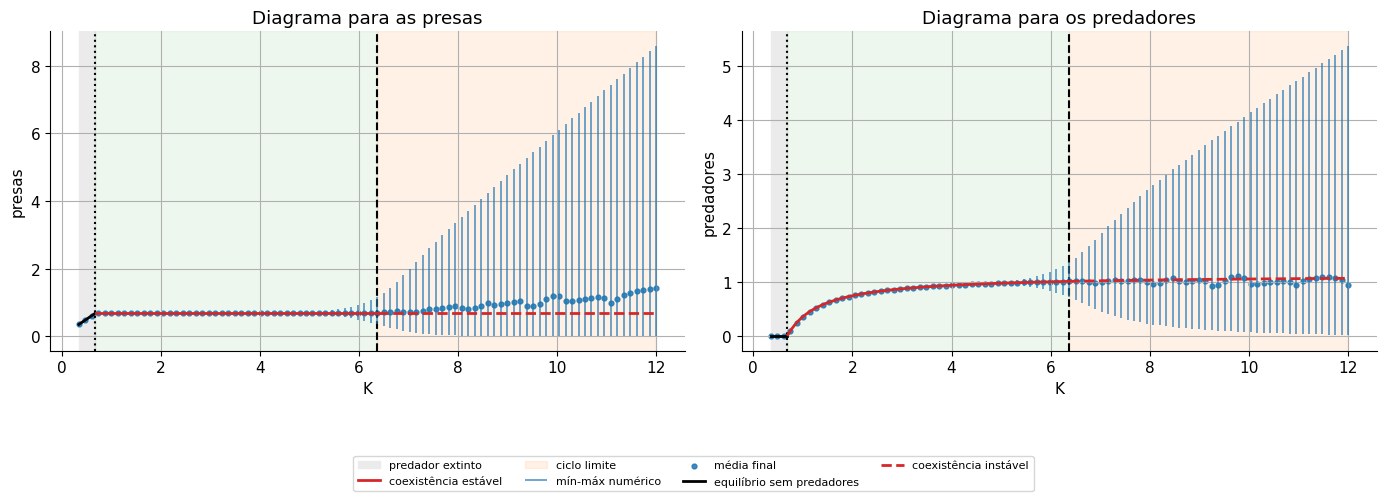

In [9]:
K_line = np.linspace(np.min(K_sweep), np.max(K_sweep), 600)
x_eq_sem_predadores = K_line
x_eq_coexistencia = np.full_like(K_line, x_star_threshold)

y_eq_coexistencia = (
    base_params["r"]
    * x_star_threshold
    * (1.0 - x_star_threshold / K_line)
    / resposta_funcional(x_star_threshold, base_params["a"], base_params["b"])
)

coexistence_mask = K_line > x_star_threshold
stable_coexistence_mask = (K_line > x_star_threshold) & (K_line < K_hopf_threshold)
unstable_coexistence_mask = K_line > K_hopf_threshold
predator_free_mask = K_line <= x_star_threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, variable, ylabel in [
    (axes[0], "x", "presas"),
    (axes[1], "y", "predadores"),
]:
    ax.axvspan(
        np.min(K_sweep),
        x_star_threshold,
        color="0.92",
        label="predador extinto",
    )
    ax.axvspan(
        x_star_threshold,
        K_hopf_threshold,
        color="tab:green",
        alpha=0.08,
        label="coexistência estável",
    )
    ax.axvspan(
        K_hopf_threshold,
        np.max(K_sweep),
        color="tab:orange",
        alpha=0.10,
        label="ciclo limite",
    )
    ax.axvline(
        x_star_threshold,
        color="black",
        linestyle=":",
        linewidth=1.5,
    )
    ax.axvline(
        K_hopf_threshold,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    ax.vlines(
        sweep_df["K"],
        sweep_df[f"{variable}_min"],
        sweep_df[f"{variable}_max"],
        color="tab:blue",
        alpha=0.65,
        linewidth=1.4,
        label="mín-máx numérico",
    )
    ax.scatter(
        sweep_df["K"],
        sweep_df[f"{variable}_mean"],
        color="tab:blue",
        s=12,
        alpha=0.85,
        label="média final",
    )
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel)

axes[0].plot(
    K_line[predator_free_mask],
    x_eq_sem_predadores[predator_free_mask],
    color="black",
    linewidth=2.0,
    label="equilíbrio sem predadores",
)
axes[0].plot(
    K_line[stable_coexistence_mask],
    x_eq_coexistencia[stable_coexistence_mask],
    color="tab:red",
    linewidth=2.0,
    label="coexistência estável",
)
axes[0].plot(
    K_line[unstable_coexistence_mask],
    x_eq_coexistencia[unstable_coexistence_mask],
    color="tab:red",
    linestyle="--",
    linewidth=2.0,
    label="coexistência instável",
)

axes[1].plot(
    K_line[predator_free_mask],
    np.zeros_like(K_line[predator_free_mask]),
    color="black",
    linewidth=2.0,
    label="equilíbrio sem predadores",
)
axes[1].plot(
    K_line[stable_coexistence_mask],
    y_eq_coexistencia[stable_coexistence_mask],
    color="tab:red",
    linewidth=2.0,
    label="coexistência estável",
)
axes[1].plot(
    K_line[unstable_coexistence_mask],
    y_eq_coexistencia[unstable_coexistence_mask],
    color="tab:red",
    linestyle="--",
    linewidth=2.0,
    label="coexistência instável",
)

axes[0].set_title("Diagrama para as presas")
axes[1].set_title("Diagrama para os predadores")

handles, labels = axes[1].get_legend_handles_labels()
unique_legend_items = dict(zip(labels, handles))

fig.legend(
    unique_legend_items.values(),
    unique_legend_items.keys(),
    loc="lower center",
    ncol=4,
    fontsize=8,
)
fig.tight_layout(rect=(0.0, 0.16, 1.0, 1.0))
plt.show()

Como interpretar o diagrama:

* a região cinza corresponde à extinção de predadores;
* a região verde corresponde à coexistência estável;
* a região laranja corresponde ao ciclo limite;
* a linha pontilhada marca o limiar de invasão dos predadores;
* a linha tracejada marca a bifurcação de Hopf;
* as barras azuis mostram a amplitude observada depois do transiente.

No regime de equilíbrio, as barras azuis praticamente colapsam em um ponto. No regime cíclico, elas abrem uma faixa: a solução passa repetidamente por valores mínimos e máximos.

## Classificando novos valores de $K$

Podemos agora transformar a análise em uma regra prática para este conjunto de parâmetros.

In [10]:
K_test_values = [0.4, 0.8, 2.0, 6.0, 7.0, 10.0]

pd.DataFrame(
    {
        "K": K_test_values,
        "regime previsto": [regime_teorico(K) for K in K_test_values],
    }
)

,K,regime previsto
0,0.4,predador extinto
1,0.8,coexistência estável
2,2.0,coexistência estável
3,6.0,coexistência estável
4,7.0,ciclo limite
5,10.0,ciclo limite


Essa classificação vem da estrutura do modelo:

* abaixo de $x_*$, os predadores não conseguem invadir;
* entre $x_*$ e $K_{\mathrm{Hopf}}$, a coexistência é localmente estável;
* acima de $K_{\mathrm{Hopf}}$, a coexistência perde estabilidade e a dinâmica converge para um ciclo.

Um detalhe importante: neste modelo, a extinção estrutural que aparece para condições iniciais positivas é a extinção dos predadores. As presas não são extintas de forma assintótica porque, quando $x$ é pequeno e $y$ também decai, o termo de crescimento das presas volta a dominar.

## Conclusão

Este exemplo mostra um fluxo de análise típico para sistemas de ODE não lineares:

1. escrever o modelo e identificar os parâmetros relevantes;
2. calcular os equilíbrios;
3. usar o Jacobiano para estudar estabilidade local;
4. simular trajetórias para verificar o comportamento global;
5. variar um parâmetro e montar um diagrama de bifurcação.

A mensagem principal é que um sistema pode mudar qualitativamente sem mudar sua forma algébrica: basta variar um parâmetro. Aqui, ao aumentar $K$, passamos de extinção de predadores para coexistência estável e depois para oscilações persistentes.